In [64]:
#pip install --upgrade --force-reinstall  git+https://github.com/kanawa12/symcontroltools

In [1]:
#pip install git+https://github.com/kanawa12/symcontroltools

import numpy as np
import sympy as sp
import control as ct
import symcontools as sct
from symcontools import dp
import knw_symtools as ks
import scipy as cp

import matplotlib
import matplotlib.pyplot as plt


In [19]:
m = cp.io.loadmat("simlog2.mat", squeeze_me=True); dp(m.keys())

dict_keys(['__header__', '__version__', '__globals__', 'err', 'ke', 'kxku', 't', 'u', 'yp'])

In [21]:
t = np.asarray(m["t"]).ravel()
u   = np.asarray(m["u"]).ravel()
yp = np.asarray(m["yp"])
kxku = np.asarray(m["kxku"])#.ravel()
ke   = np.asarray(m["ke"])          # (N,4)
err = np.asarray(m["err"])

In [66]:
import control as ct

# zpk -> tf -> ss
def getzpkss(z,p,k):
    Gp = ct.zpk(z,p,k)          # continuous-time
    Gs = ct.ss(Gp)

    # modal canonical form
    Gm, T = ct.modal_form(Gs)     # A が（ほぼ）対角/ブロック対角
    A, B, C, D = Gm.A, Gm.B, Gm.C, Gm.D
    C[0,0] = B[0,0]*C[0,0]
    C[0,1] = B[1,0]*C[0,1]
    B = np.array([[1], [1]])
    return sp.Tuple(A,B,C,D)

dp(getzpkss(-1, [-3,-4], 2))
dp(getzpkss(-1, [-2,-6], 3))

([[-4.00000000000001, -1.77635683940025e-15], [1.77635683940025e-15, -2.99999999999999]], [[1], [1]], [[5.99999999999993, -3.99999999999993]], [[0.0]])

([[-6.0, -4.44089209850063e-16], [-4.44089209850063e-16, -2.0]], [[1], [1]], [[3.75, -0.750000000000001]], [[0.0]])

C:\Users\kawan\AppData\Local\Temp\ipykernel_86856\1509679087.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


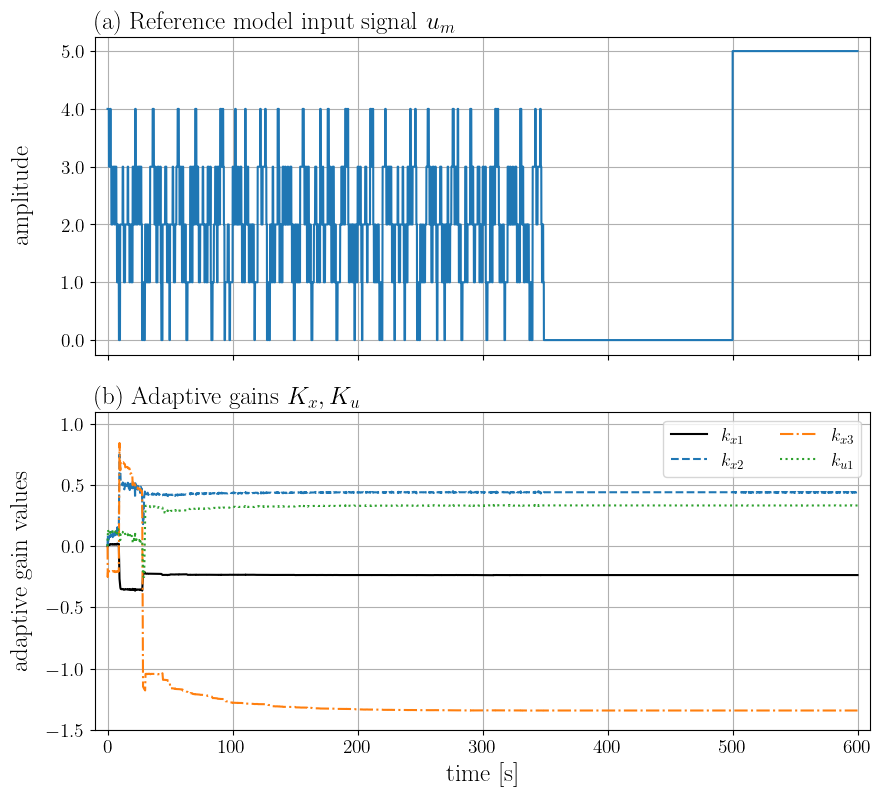

In [54]:


# （任意）間引き：重いなら step を 5,10,20... に
step_u = 1
step_k = 5



plt.rcParams.update({
    "font.size": 18,          # 基本サイズ
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

# （任意）LaTeX組版（TeX環境があるなら）
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(10, 9),
    gridspec_kw={"height_ratios": [2.0, 2.0], "hspace": 0.18},
)

# 上段：u_m
ax1.plot(t[::step_u], u[::step_u], linewidth=1.5)


styles = ['-', '--', '-.', ':']
colors = ['k', 'tab:blue', 'tab:orange', 'tab:green']

for i in range(kxku.shape[1]):
    ax2.plot(
        t[::step_k],
        kxku[::step_k, i],
        linestyle=styles[i],
        color=colors[i],
        linewidth=1.5
    )

ax1.set_ylabel(r"amplitude", labelpad = 20)
ax1.grid(True)

ax1.set_xlim(-10, 610)

# 下段：kkxulog（4本）
#ax2.plot(k_t[::step_k], K[::step_k, :], linewidth=1.5)
ax2.set_xlabel(r"time $[\mathrm{s}]$")
ax2.set_ylabel(r"adaptive gain values", labelpad = 10)
ax2.grid(True)

# 凡例：2×2
ax2labels = [r"$k_{x 1}$", r"$k_{x 2}$", r"$k_{x 3}$", r"$k_{u 1}$"]
ax2.legend(ax2labels, ncol=2, loc="upper right", frameon=True)

# 軸範囲を揃えたいなら（例）
# ax2.set_xlim(0, 500)

#ax1.set_ylim(-0.2, 4.2)
ax2.set_ylim(-1.5, 1.1)


ax1.set_title(r"(a) Reference model input signal $u_m$", loc="left")
ax2.set_title(r"(b) Adaptive gains $K_x, K_u$", loc="left")

ax1.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.1f'))

fig.tight_layout()
plt.show()
fig.savefig("two_panel.pdf", bbox_inches="tight", pad_inches=0.030)  # 外枠を切って保存


C:\Users\kawan\AppData\Local\Temp\ipykernel_86856\4159148560.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


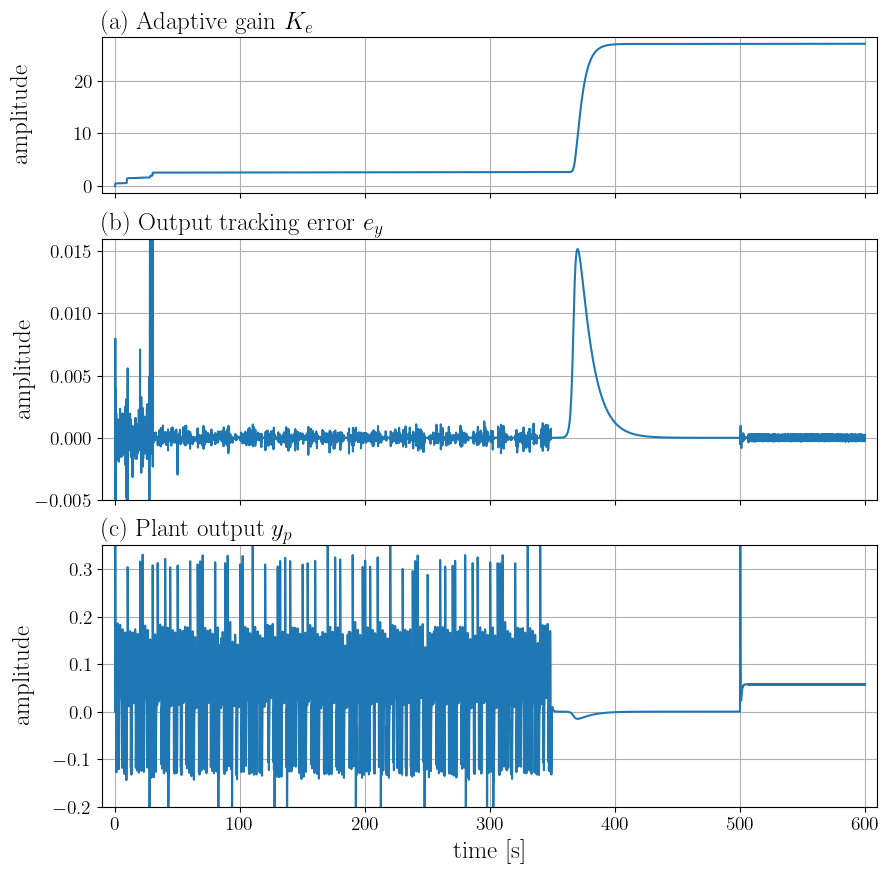

In [53]:


# （任意）間引き：重いなら step を 5,10,20... に
step_u = 1
step_k = 1



plt.rcParams.update({
    "font.size": 18,          # 基本サイズ
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

# （任意）LaTeX組版（TeX環境があるなら）
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(10, 10),
    gridspec_kw={"height_ratios": [0.6, 1.0, 1.0], "hspace": 0.2},
)

# 上段：u_m
ax1.plot(t[::step_u], ke[::step_u], linewidth=1.5)
ax2.plot(t[::step_u], err[::step_u], linewidth=1.5)
ax3.plot(t[::step_u], yp[::step_u], linewidth=1.5)
"""
styles = ['-', '--', '-.', ':']
colors = ['k', 'tab:blue', 'tab:orange', 'tab:green']

for i in range(kxku.shape[1]):
    ax2.plot(
        t[::step_k],
        kxku[::step_k, i],
        linestyle=styles[i],
        color=colors[i],
        linewidth=1.5
    )
"""


ax1.grid(True)
ax2.grid(True)
ax3.grid(True)

ax1.set_xlim(-10, 610)

# 下段：kkxulog（4本）
#ax2.plot(k_t[::step_k], K[::step_k, :], linewidth=1.5)


ax1.set_ylabel(r"amplitude", labelpad = 30)
ax2.set_ylabel(r"amplitude", labelpad = 0)
ax3.set_ylabel(r"amplitude", labelpad = 14)

ax3.set_xlabel(r"time $[\mathrm{s}]$")



# 凡例：2×2
#ax2labels = [r"$k_{x 1}$", r"$k_{x 2}$", r"$k_{x 3}$", r"$k_{u 1}$"]
#ax2.legend(ax2labels, ncol=2, loc="upper right", frameon=True)

# 軸範囲を揃えたいなら（例）
# ax2.set_xlim(0, 500)

ax2.set_ylim(-0.005, 0.016)
ax3.set_ylim(-0.2, 0.35)


ax1.set_title(r"(a) Adaptive gain $K_e$", loc="left")
ax2.set_title(r"(b) Output tracking error $e_y$", loc="left")
ax3.set_title(r"(c) Plant output $y_p$", loc="left")

#ax1.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.1f'))

fig.tight_layout()
plt.show()
fig.savefig("two_panel2.pdf", bbox_inches="tight", pad_inches=0.030)  # 外枠を切って保存


In [69]:
m = loadmat("zerodif.mat", squeeze_me=True); dp(m.keys())

zs = np.asarray(m["zs"]).ravel()
cs = np.asarray(m["cs"])
zs = -1*zs
zs


dict_keys(['__header__', '__version__', '__globals__', 'cs', 'zs'])

array([-0. , -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1. ,
       -1.1, -1.2, -1.3, -1.4, -1.5, -1.6, -1.7, -1.8, -1.9, -2. ])

[-1.23171852e+02 -9.86280575e+01 -9.23126474e+01 -3.01304164e+02
 -3.65479516e+02 -4.07365426e+02 -3.37031353e+02  7.12556196e+01
  1.86487342e+02  5.94099097e+01 -6.47879230e-03 -2.99405116e+01
 -4.47440212e+01 -5.28531762e+01 -5.78861885e+01 -6.10715192e+01
 -6.31716764e+01 -6.44595023e+01 -6.53513916e+01 -6.59493658e+01
 -6.64631779e+01]
[-6.70591897e+01  2.52643901e+01 -2.84326678e+01 -3.85754182e+02
 -3.73968449e+02 -3.66202886e+02 -2.84318482e+02  5.09777507e+01
  1.42800250e+02  4.51646647e+01  1.73218057e-02 -2.24882505e+01
 -3.41790700e+01 -4.12239744e+01 -4.60089162e+01 -4.94929118e+01
 -5.21560662e+01 -5.42368794e+01 -5.59712942e+01 -5.74342828e+01
 -5.87062903e+01]
[-3.01143485e+02 -2.08950914e+02 -5.03257357e+02 -3.99727447e+02
 -1.75145608e+02 -2.18356548e+02 -3.75601997e+02 -2.19473400e+02
  6.61409928e+01  3.28781309e+01 -6.36120631e-03 -2.53545192e+01
 -4.39521876e+01 -5.78898528e+01 -6.85924565e+01 -7.70976445e+01
 -8.39454931e+01 -8.97540038e+01 -9.45941935e+01 -9.88

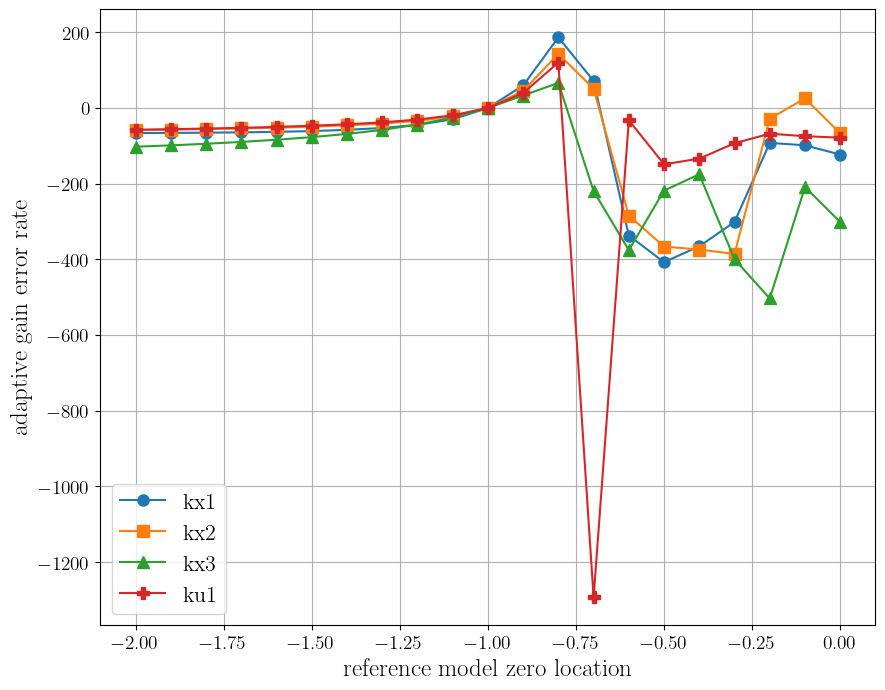

In [70]:


plt.figure(figsize=(10, 8))

plt.rcParams.update({
    "font.size": 20,          # 基本サイズ
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
})

# 3つの系列をループしてプロット
markers = ['o', 's', '^', "P"]
for i, y_data in enumerate(cs):
    print(y_data)
    if i < 3:
        plt.plot(zs, y_data, marker=markers[i], label=f'kx{i+1}', markersize=8)
    else:
        plt.plot(zs, y_data, marker=markers[i], label="ku1", markersize=8)

# 軸ラベルとタイトルの設定
plt.xlabel('reference model zero location')
plt.ylabel('adaptive gain error rate')
#plt.title('Line Plot of km vs Bf')

plt.grid(True) # グリッド（目盛線）を表示
plt.legend() # 凡例を表示
plt.show()

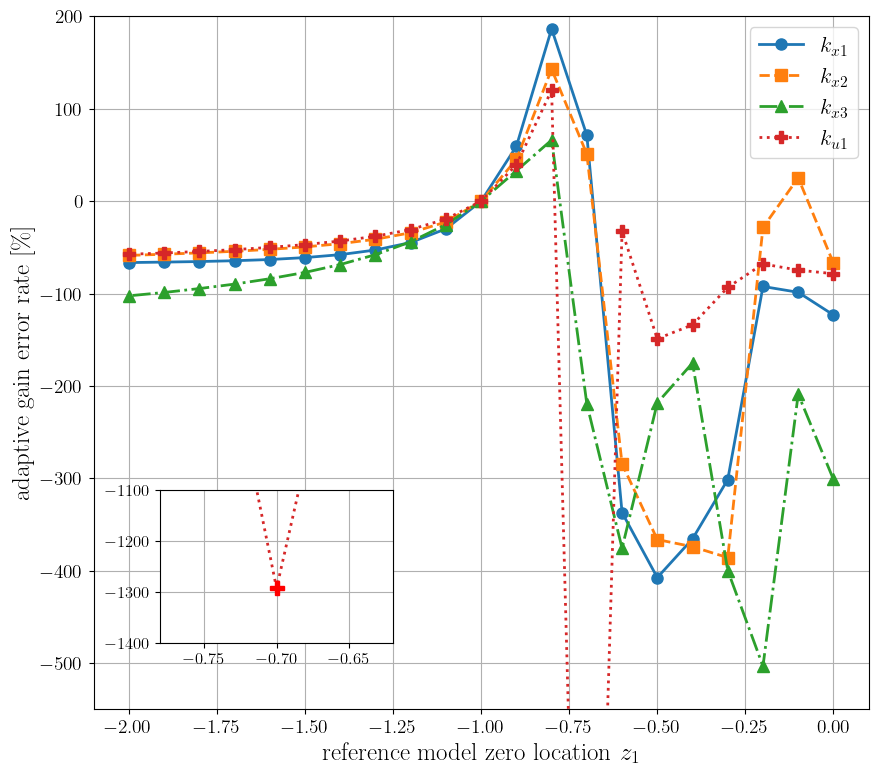

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.figure(figsize=(10, 9))

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
})

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

zs_arr = np.asarray(zs, dtype=float)
markers = ['o', 's', '^', 'P']
linstyles=["-", "--", "-.", ":"]

# 主図で見たいyレンジ（ここを調整）
ylow, yhigh = -550, 200

# 外れ値小窓のyレンジ（ここを調整）
yout_low, yout_high = -1400, -1100

# 外れ値の点（既知）
z_out = -0.7
idx_out = int(np.argmin(np.abs(zs_arr - z_out)))

ax = plt.gca()

# ===== 主図（通常レンジだけ描く：レンジ外はNaNにして線が変にならないように） =====
for i, y_data in enumerate(cs):
    y = np.asarray(y_data, dtype=float)

    if i < 3:
        label = rf'$k_{{x{i+1}}}$'
    else:
        label = r'$k_{u1}$'   # ついでに下付き表記

    ax.plot(
        zs_arr, y,
        marker=markers[i], markersize=8,
        label=label,
        linestyle=linstyles[i], linewidth=2
    )

ax.set_ylim(ylow, yhigh)
ax.set_xlabel(r'reference model zero location $z_{1}$')
ax.set_ylabel(r'adaptive gain error rate [\%]')
ax.grid(True)
ax.legend(loc='upper right')
#ax.axvline(x=1, color='0.2', linewidth=2)
#ax.axhline(y=0, color='0.2', linewidth=2)

# 主図に inset が見ている x 範囲を帯で示す
#ax.axvspan(z_out - xpad, z_out + xpad, alpha=0.15, zorder=0)
#from mpl_toolkits.axes_grid1.inset_locator import mark_inset
#mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.2", lw=1.5)

# ===== inset（外れ値付近） =====
axins = inset_axes(ax, width="30%", height="22%", loc="lower left", borderpad=3)

for i, y_data in enumerate(cs):
    y = np.asarray(y_data, dtype=float)
    axins.plot(
        zs_arr, y,
        marker=markers[i], markersize=6,
        linestyle=linstyles[i], linewidth=2
    )


# 外れ値点を強調（任意）
y_ku1 = np.asarray(cs[3], dtype=float)  # ku1が4番目(=i==3)という前提
axins.plot([zs_arr[idx_out]], [y_ku1[idx_out]], marker='P', markersize=10, linestyle='None', color="red")

# insetの表示範囲：xは外れ値の周囲だけに絞ると分かりやすい
xpad = 0.08
axins.set_xlim(z_out - xpad, z_out + xpad)
axins.set_ylim(yout_low, yout_high)

axins.grid(True)
axins.tick_params(labelsize=12)
plt.savefig("two_panelaa.pdf", bbox_inches="tight")#, pad_inches=0.030)
plt.show()


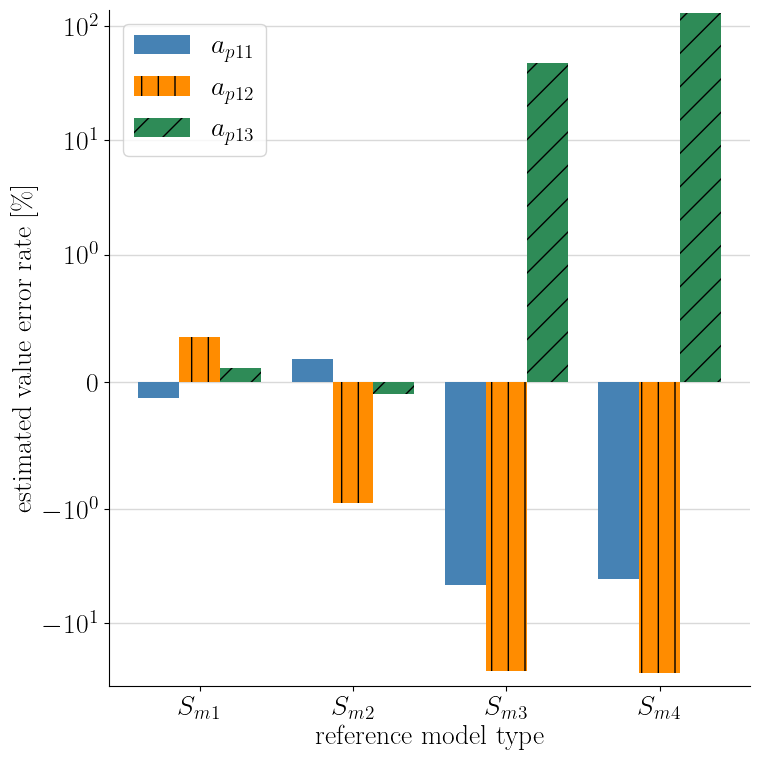

In [72]:
import numpy as np
import matplotlib.pyplot as plt

def grouped_bar(ax, Y, xlabels=None, series_labels=None, width=0.8):
    """
    Y: shape (n_series, n_points) の2次元配列（系列×点）
    xlabels: 各点のラベル（長さ n_points）
    series_labels: 各系列のラベル（長さ n_series）
    width: 1グループ全体の幅（0～1くらい）
    """
    Y = np.asarray(Y)
    if Y.ndim != 2:
        raise ValueError("Y must be 2D: (n_series, n_points)")

    n_series, n_points = Y.shape
    x = np.arange(n_points)

    bar_w = width / n_series
    offsets = (np.arange(n_series) - (n_series - 1) / 2) * bar_w

    for i in range(n_series):
        label = series_labels[i] if series_labels is not None else None
        ax.bar(x + offsets[i], Y[i], width=bar_w, label=label, color=colors[i], hatch=hatches[i])

    ax.set_xticks(x)
    if xlabels is not None:
        ax.set_xticklabels(xlabels)

    ax.yaxis.grid(True, color="0.85", linewidth=1)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax


# ===== 使用例（4系列）=====
xlabels = [r"$S_{m1}$", r"$S_{m2}$", r"$S_{m3}$", r"$S_{m4}$"]
Y = np.array([
    [-7*10e-3, 0.017, -6*10e-3, 0.1],   # series 1
    [-0.025, -3.7*10e-3, 0.054, -0.07],   # series 2
    [-32, -26, -57, -35],   # series 3
    [-54, -42, -120, -46],   # series 4
]).T
Y = np.array([
    [-0.13, 0.35, 0.11],   # series 1
    [0.18, -0.95, -0.096],   # series 2
    [-4.6, -26, 47],   # series 3
    [-4.1, -27, 130],   # series 4
]).T



series_labels = [r"$a_{p 11}$", r"$a_{p 12}$", r"$a_{p 13}$",]
hatches = ["", "|", "/"]
colors = ["steelblue", "darkorange", "seagreen"]
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

fig, ax = plt.subplots(figsize=(8, 8))
grouped_bar(ax, Y, xlabels=xlabels, series_labels=series_labels, width=0.8)

#ax.set_ylim(-100, 1)
ax.set_yscale("symlog", linthresh=1)
ax.legend(ncol=1, loc="upper left",  frameon=True)

ax.set_xlabel(r'reference model type')
ax.set_ylabel(r'estimated value error rate [\%]')
#ax.grid(True)

plt.tight_layout()
plt.savefig("esterr.pdf", bbox_inches="tight")
plt.show()

In [73]:

z = [-0.75+0.19j, -0.75-0.19j]
p = [-0.1, -0.25+0.66j, -0.25-0.66j]
k = 1

mats = sct.zpk_to_observable_canonical(z, p, k)
dp(sp.Tuple(*mats))
cp.signal.zpk2tf(z,p,k)

([[0.0, 0.0, -0.04981], [1.0, 0.0, -0.5481], [0.0, 1.0, -0.6]], [[1.0], [1.5], [0.5986]], [[0.0, 0.0, 1.0]], [[0.0]])

(array([1.    , 1.5   , 0.5986]), array([1.     , 0.6    , 0.5481 , 0.04981]))

In [74]:
import sys, site
print("python:", sys.executable)
print("prefix:", sys.prefix)
print("usersite:", site.getusersitepackages())


python: c:\Users\kawan\anaconda3\envs\python-std-gl-p313\python.exe
prefix: c:\Users\kawan\anaconda3\envs\python-std-gl-p313
usersite: C:\Users\kawan\AppData\Roaming\Python\Python313\site-packages


In [75]:


s = sp.symbols("s")
#tup = sct.ss_to_mats(sct.zpk_to_observable_canonical([-0.75, -0.5], [0.1, -0.25+0.66j, -0.25-0.66j], 10))


import json

import re

def json_compact_keep_newline_after_bracket_comma(s: str) -> str:
    """
    JSON整形向け:
    - '],<newline>' の改行だけ残す
    - それ以外の改行は削除
    - 残した改行の直後にあるインデント（空白/タブ）も削除
    """
    token = "__KEEP_NL__"

    # 1) '],\r?\n' をトークンに退避
    s = re.sub(r"\],\r?\n", "]," + token, s)

    # 2) 残りの改行は全部削除
    s = re.sub(r"\r?\n", "", s)

    # 3) トークンを改行に戻し、直後のインデントを削除
    #    "__KEEP_NL__[ \t]*" -> "\n"
    s = re.sub(token + r"[ \t]*", "\n", s)

    return s



from typing import Any, Dict

def mat_cast_list(mats: tuple, digits=10):
    m2 = []
    for M in mats:
        m2.append( [[round(float(x), digits) for x in row] for row in M.tolist()] )
    return m2

def mat_to_dict(mats : tuple):
    return dict(zip(["A","B","C","D"], mats))

def dumps_named_object(
    name: str,
    body: Dict[str, Any],
    *,
    ensure_ascii: bool = False,
    keep_newline_after_bracket_comma: bool = True,
) -> str:
    """
    name付きオブジェクトとしてJSON文字列を生成する。
    - まず compact JSON (separators) で生成 → インデントは原理的に出ない
    - 必要なら '],' の後だけ改行を入れる（あなたの用途向け）
    """
    s = json.dumps(
        {name: body},
        ensure_ascii=ensure_ascii,
        separators=(",", ":"),   # 余計な空白・改行を最初から出さない
    )
    if keep_newline_after_bracket_comma:
        s = re.sub(r"\],", "],\n", s)
    return s



def ss_tuple_to_json_str(smat, digits=10):
    A, B, C, D = smat  # tup = (A,B,C,D), each is a SymPy Matrix (ImmutableDenseMatrix ok)

    def conv(M):
        return [[round(float(x), digits) for x in row] for row in M.tolist()]

    data = {
        "Ap": conv(A),
        "Bp": conv(B),
        "Cp": conv(C),
        "Dp": conv(D),
    }
    return json.dumps(data, ensure_ascii=False, indent=0)

# 使い方:
#json_str = json_compact_keep_newline_after_bracket_comma(ss_tuple_to_json_str(tup))
#print(json_str)
#print(dumps_named_object("plant", mat_to_dict(mat_cast_list(tup))))


In [76]:
def makesyms(s1, s2, x, y):
    st = ""
    for i in range(x):
        for j in range(y):
            """
            if x == 1:
                st = st + "{" + s1 + "_" + s2 + r"}_{" + str(j+1)  + "} "
            elif y == 1:
                st = st + "{" + s1 + "_" + s2 + r"}_{" + str(i+1)  + "} "
            else:
                """
            st = st + "{" + s1 + "_" + s2 + r"}_{" + str(i+1) + str(j+1)  + "} "
    syms = sp.symbols(st)
    if x == 1 and y == 1:
        syms = [syms, ]
    return sp.Matrix(syms).reshape(x, y)

def make_single_syms(s1, s2, x, y):
    st = ""
    n = max(x,y)
    for i in range(n):
        st = st + "{" + s1 + "_" + s2 + r"}_{" + str(i+1) + "} "
    syms = sp.symbols(st)
    if x == 1 and y == 1:
        syms = [syms, ]
    return sp.Matrix(syms).reshape(x, y)


In [77]:




def sym_setting(pdim, rdim, maindict):
    Cmsyms = makesyms("c", "m", 1, pdim)
    Amsyms = makesyms("a", "m", rdim, rdim)
    Apsyms = makesyms("a", "p", pdim, pdim)
    Bmsyms = makesyms("b", "m", rdim, 1)
    Bpsyms = makesyms("b", "p", pdim, 1)
    Cmsyms = makesyms("c", "m", 1, pdim)
    Cpsyms = makesyms("c", "p", 1, rdim)
    Dmsyms = sp.Matrix([[0]]) #makesyms("d", "m", 1, 1)
    Dpsyms = sp.Matrix([[0]]) #makesyms("d", "p", 1, 1)

    sp_bases = (Apsyms, Bpsyms, Cpsyms, Dpsyms)
    sm_bases = (Amsyms, Bmsyms, Cmsyms, Dmsyms)
    maindict["sp_bases"] = sp_bases
    maindict["sm_bases"] = sm_bases


    maindict["Am"] = sp.Tuple(Amsyms); maindict["Bm"] = sp.Tuple(Bmsyms); maindict["Cm"] = sp.Tuple(Cmsyms) ;maindict["Dm"] = sp.Tuple(Dmsyms)
    maindict["Ap"] = sp.Tuple(Apsyms); maindict["Bp"] = sp.Tuple(Bpsyms); maindict["Cp"] = sp.Tuple(Cpsyms) ;maindict["Dp"] = sp.Tuple(Dpsyms)
    #display(sp.Dict(maindict))
    #display(sp.srepr(sp.Dict(sdict)))


    ssmode_p = "obs" # "diag" # "ctrl"
    ssmode_ref = ssmode_p

    app = ks.make_sym_canonform(sp_bases, ssmode_p)
    amp = ks.make_sym_canonform(sm_bases, ssmode_ref)
    #app[3] = sp.Matrix([[0]]); amp[3] = sp.Matrix([[0]])

    maindict["sp_"+ssmode_p] = app
    maindict["sm_"+ssmode_ref] = amp

    adddict = {"Am": amp[0], "Bm": amp[1], "Cm": amp[2], "Dm": amp[3],
               "Ap": app[0], "Bp": app[1], "Cp": app[2], "Dp": app[3],}

    ks.addparam(maindict, adddict)

    sasyms = makesyms("s", "x", rdim, rdim)
    sbsyms = makesyms("s", "u", pdim, 1)
    Kxsyms = makesyms("k", "x", 1, rdim)
    Kusyms = makesyms("k", "u", 1, 1)

    sskk_bases = (sasyms, sbsyms, Kxsyms, Kusyms)

    maindict["kxku"] = sp.Tuple(sp.Matrix([*Kxsyms, *Kusyms]), sp.Matrix([*Kxsyms, *Kusyms]))
    maindict["kxkut"] = maindict["kxku"]
    maindict["sskk_bases"] = sskk_bases

    return maindict

def make_CGTEqs(SSKK, sp_obs, sm_obs):
    Aps = sp.Matrix([[sp_obs[0], sp_obs[1]], [sp_obs[2], sp_obs[3]]])
    SKs = sp.Matrix([[SSKK[0], SSKK[1]], [SSKK[2], SSKK[3]]])
    Ams = sp.Matrix([ [sp.MatMul(SSKK[0], sm_obs[0]).doit(), sp.MatMul(SSKK[0], sm_obs[1]).doit()],
                    [sm_obs[2], sm_obs[3]] ])
    KAS = sp.Tuple(Aps, SKs, Ams); 
    expr = Aps*SKs - Ams
    return expr, KAS

def eq_to_unimat(cgt_expr, abvals, kxvals, pdim):
    abmat = sp.Matrix(abvals).reshape(pdim*2, 1) #未知数ベクトル
    kmat  = sp.Matrix(kxvals).reshape(len(kxvals), 1)

    mats = sp.linear_eq_to_matrix(cgt_expr, abvals)
    th = ks.partial_rref(sp.Matrix([[*mats]]), pdim )
    #th[-1, :] /= th[-1, -1] # 最後の行を正規化
    abans = sp.Tuple(th[:, :-1], abmat, th[:, -1])
    # 方程式を求める
    reeq = sp.expand(th[:, :-1]@abmat - th[:, -1])
    keqmats = sp.linear_eq_to_matrix(reeq, kxvals)
    kans = sp.Tuple(keqmats[0], kmat, keqmats[1])
    return reeq, abans, kans




In [78]:
#sa = [*sasyms.reshape(sasyms.shape[0]**2, 1)]
#sb = [*sbsyms.reshape(sbsyms.shape[0], 1)]
#active_sab_set = ( set(sa) | set(sb) )
"""
def elim_in_obs(sasyms, sbsyms):
    zrod = {}
    for i in sasyms[-1,:-1]:
        zrod[i] = 0
    zrod[sasyms[-1,-1]] = 1
    zrod[sbsyms[-1,0]] = 0
    return zrod
"""

"""
if ssmode == "obs":
    zrod = elim_in_obs(sasyms, sbsyms)
    expr = expr.subs(zrod)
    active_sab_set -= set(zrod)
"""
#print(active_sab_set)

"""
手動で解く場合
ex = expr.subs( sasyms[1,0], sp.solve(expr[-3] , sasyms[1,0])[0] )
ex = ex.subs( sbsyms[1,0], sp.solve(expr[-1] , sbsyms[1,0])[0] ); dp(sp.simplify(sp.expand(ex)))
ex = ex.subs( sasyms[1,1], sp.solve(expr[-2] , sasyms[1,1])[0] ); dp(sp.simplify(sp.expand(ex)))
ex = ex.subs( sasyms[0,1], sp.solve(expr[0] , sasyms[0,1])[0] ); dp(sp.simplify(sp.expand(ex)))
ex = ex.subs( sasyms[0,0], sp.solve(expr[1] , sasyms[0,0])[0] ); dp(sp.simplify(sp.expand(ex)))
dp(sp.simplify(sp.expand(ex)))
"""

#vals = list(active_sab_set)
#print(list(active_sab_set).sort())
#def solve_expr(expr):

#dp(sp.Eq(sskk[0], sxsu_solved[0], evaluate=False), is_latex=True)
#dp(sp.Eq(sskk[1], sxsu_solved[1], evaluate=False), is_latex=True)


'\n手動で解く場合\nex = expr.subs( sasyms[1,0], sp.solve(expr[-3] , sasyms[1,0])[0] )\nex = ex.subs( sbsyms[1,0], sp.solve(expr[-1] , sbsyms[1,0])[0] ); dp(sp.simplify(sp.expand(ex)))\nex = ex.subs( sasyms[1,1], sp.solve(expr[-2] , sasyms[1,1])[0] ); dp(sp.simplify(sp.expand(ex)))\nex = ex.subs( sasyms[0,1], sp.solve(expr[0] , sasyms[0,1])[0] ); dp(sp.simplify(sp.expand(ex)))\nex = ex.subs( sasyms[0,0], sp.solve(expr[1] , sasyms[0,0])[0] ); dp(sp.simplify(sp.expand(ex)))\ndp(sp.simplify(sp.expand(ex)))\n'

In [79]:
def derive_CGTEq(maindict):
    pdim = 3; rdim = pdim
    maindict = sym_setting(pdim, rdim, maindict=maindict)
    dp(sp.Dict(maindict))

    maindict["CGT_expr"] , maindict["KAS"] = make_CGTEqs(maindict["sskk_bases"], maindict["sp_obs"], maindict["sm_obs"])
    expr = maindict["CGT_expr"].reshape((pdim+1)**2, 1)

    dp(maindict["CGT_expr"]); dp(maindict["KAS"])
    dp(expr)

    vals = list(maindict["sskk_bases"][0]) + list(maindict["sskk_bases"][1])
    ssmat, ssmaty = sp.linear_eq_to_matrix(expr, vals)
    E, ssdict = ks.solve_S(sp.Matrix([[ssmat, ssmaty]]), vals)

    dp(sp.Tuple(ssmat,sp.Matrix([vals]).T, ssmaty))
    dp(E); dp(sp.Dict(ssdict))
    print("S was solved")

    SKs = maindict["KAS"][1]
    sxsu_solved = SKs.subs(ssdict)
    dp(sp.Eq(SKs, sxsu_solved, evaluate=False))
    maindict["sxsu_solved"] = sxsu_solved

    exprs2 = ks.elim_zero_row(sp.simplify(expr.subs(ssdict)))
    abvals = [*maindict["Ap"][0][:,-1], *maindict["Bp"][0][:,-1]]
    kxvals = [*maindict["kxku"][0]]
    maindict["cgteqs"], maindict["estans"], maindict["cgtans"] = eq_to_unimat(exprs2, abvals, kxvals, pdim)
    return maindict

maindict = {
    "Am": sp.Tuple(), "Bm": sp.Tuple(), "Cm": sp.Tuple(), "Dm": sp.Tuple(), #"Cmdiag": sp.Tuple(),
    "Ap": sp.Tuple(), "Bp": sp.Tuple(), "Cp": sp.Tuple(), "Dp": sp.Tuple(), #"Cpdiag": sp.Tuple(),
    "kxku": sp.Tuple(), "kxkut": sp.Tuple(),
    "KAS": sp.Tuple(), "estans": sp.Tuple(),
}
display(maindict)

maindict = derive_CGTEq(maindict)




{'Am': (),
 'Bm': (),
 'Cm': (),
 'Dm': (),
 'Ap': (),
 'Bp': (),
 'Cp': (),
 'Dp': (),
 'kxku': (),
 'kxkut': (),
 'KAS': (),
 'estans': ()}

{Am: (Matrix([
[{a_m}_{11}, {a_m}_{12}, {a_m}_{13}],
[{a_m}_{21}, {a_m}_{22}, {a_m}_{23}],
[{a_m}_{31}, {a_m}_{32}, {a_m}_{33}]]), Matrix([
[0, 0, {a_m}_{13}],
[1, 0, {a_m}_{23}],
[0, 1, {a_m}_{33}]])), Ap: (Matrix([
[{a_p}_{11}, {a_p}_{12}, {a_p}_{13}],
[{a_p}_{21}, {a_p}_{22}, {a_p}_{23}],
[{a_p}_{31}, {a_p}_{32}, {a_p}_{33}]]), Matrix([
[0, 0, {a_p}_{13}],
[1, 0, {a_p}_{23}],
[0, 1, {a_p}_{33}]])), Bm: (Matrix([
[{b_m}_{11}],
[{b_m}_{21}],
[{b_m}_{31}]]), Matrix([
[{b_m}_{11}],
[{b_m}_{21}],
[{b_m}_{31}]])), Bp: (Matrix([
[{b_p}_{11}],
[{b_p}_{21}],
[{b_p}_{31}]]), Matrix([
[{b_p}_{11}],
[{b_p}_{21}],
[{b_p}_{31}]])), Cm: (Matrix([[{c_m}_{11}, {c_m}_{12}, {c_m}_{13}]]), Matrix([[0, 0, 1]])), Cp: (Matrix([[{c_p}_{11}, {c_p}_{12}, {c_p}_{13}]]), Matrix([[0, 0, 1]])), Dm: (Matrix([[0]]), Matrix([[0]])), Dp: (Matrix([[0]]), Matrix([[0]])), KAS: (), estans: (), kxku: (Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_x}_{13}],
[{k_u}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_x}_{13}],
[{k

Matrix([
[             {a_p}_{13}*{s_x}_{31} + {b_p}_{11}*{k_x}_{11} - {s_x}_{12},              {a_p}_{13}*{s_x}_{32} + {b_p}_{11}*{k_x}_{12} - {s_x}_{13},              -{a_m}_{13}*{s_x}_{11} - {a_m}_{23}*{s_x}_{12} - {a_m}_{33}*{s_x}_{13} + {a_p}_{13}*{s_x}_{33} + {b_p}_{11}*{k_x}_{13},              {a_p}_{13}*{s_u}_{31} - {b_m}_{11}*{s_x}_{11} - {b_m}_{21}*{s_x}_{12} - {b_m}_{31}*{s_x}_{13} + {b_p}_{11}*{k_u}_{11}],
[{a_p}_{23}*{s_x}_{31} + {b_p}_{21}*{k_x}_{11} + {s_x}_{11} - {s_x}_{22}, {a_p}_{23}*{s_x}_{32} + {b_p}_{21}*{k_x}_{12} + {s_x}_{12} - {s_x}_{23}, -{a_m}_{13}*{s_x}_{21} - {a_m}_{23}*{s_x}_{22} - {a_m}_{33}*{s_x}_{23} + {a_p}_{23}*{s_x}_{33} + {b_p}_{21}*{k_x}_{13} + {s_x}_{13}, {a_p}_{23}*{s_u}_{31} - {b_m}_{11}*{s_x}_{21} - {b_m}_{21}*{s_x}_{22} - {b_m}_{31}*{s_x}_{23} + {b_p}_{21}*{k_u}_{11} + {s_u}_{11}],
[{a_p}_{33}*{s_x}_{31} + {b_p}_{31}*{k_x}_{11} + {s_x}_{21} - {s_x}_{32}, {a_p}_{33}*{s_x}_{32} + {b_p}_{31}*{k_x}_{12} + {s_x}_{22} - {s_x}_{33}, -{a_m}_{13}*{s_x}_

(Matrix([
[0, 0, {a_p}_{13}, {b_p}_{11}],
[1, 0, {a_p}_{23}, {b_p}_{21}],
[0, 1, {a_p}_{33}, {b_p}_{31}],
[0, 0,          1,          0]]), Matrix([
[{s_x}_{11}, {s_x}_{12}, {s_x}_{13}, {s_u}_{11}],
[{s_x}_{21}, {s_x}_{22}, {s_x}_{23}, {s_u}_{21}],
[{s_x}_{31}, {s_x}_{32}, {s_x}_{33}, {s_u}_{31}],
[{k_x}_{11}, {k_x}_{12}, {k_x}_{13}, {k_u}_{11}]]), Matrix([
[{s_x}_{12}, {s_x}_{13}, {a_m}_{13}*{s_x}_{11} + {a_m}_{23}*{s_x}_{12} + {a_m}_{33}*{s_x}_{13}, {b_m}_{11}*{s_x}_{11} + {b_m}_{21}*{s_x}_{12} + {b_m}_{31}*{s_x}_{13}],
[{s_x}_{22}, {s_x}_{23}, {a_m}_{13}*{s_x}_{21} + {a_m}_{23}*{s_x}_{22} + {a_m}_{33}*{s_x}_{23}, {b_m}_{11}*{s_x}_{21} + {b_m}_{21}*{s_x}_{22} + {b_m}_{31}*{s_x}_{23}],
[{s_x}_{32}, {s_x}_{33}, {a_m}_{13}*{s_x}_{31} + {a_m}_{23}*{s_x}_{32} + {a_m}_{33}*{s_x}_{33}, {b_m}_{11}*{s_x}_{31} + {b_m}_{21}*{s_x}_{32} + {b_m}_{31}*{s_x}_{33}],
[         0,          0,                                                                     1,                                         

Matrix([
[                                                                         {a_p}_{13}*{s_x}_{31} + {b_p}_{11}*{k_x}_{11} - {s_x}_{12}],
[                                                                         {a_p}_{13}*{s_x}_{32} + {b_p}_{11}*{k_x}_{12} - {s_x}_{13}],
[             -{a_m}_{13}*{s_x}_{11} - {a_m}_{23}*{s_x}_{12} - {a_m}_{33}*{s_x}_{13} + {a_p}_{13}*{s_x}_{33} + {b_p}_{11}*{k_x}_{13}],
[              {a_p}_{13}*{s_u}_{31} - {b_m}_{11}*{s_x}_{11} - {b_m}_{21}*{s_x}_{12} - {b_m}_{31}*{s_x}_{13} + {b_p}_{11}*{k_u}_{11}],
[                                                            {a_p}_{23}*{s_x}_{31} + {b_p}_{21}*{k_x}_{11} + {s_x}_{11} - {s_x}_{22}],
[                                                            {a_p}_{23}*{s_x}_{32} + {b_p}_{21}*{k_x}_{12} + {s_x}_{12} - {s_x}_{23}],
[-{a_m}_{13}*{s_x}_{21} - {a_m}_{23}*{s_x}_{22} - {a_m}_{33}*{s_x}_{23} + {a_p}_{23}*{s_x}_{33} + {b_p}_{21}*{k_x}_{13} + {s_x}_{13}],
[ {a_p}_{23}*{s_u}_{31} - {b_m}_{11}*{s_x}_{21

KeyboardInterrupt: 

In [ ]:
# 表示のみ
dp(maindict["cgteqs"], "もとの方程式")
dp(maindict["estans"], "プラントパラメータについて整理したもの")
dp(maindict["cgtans"], "適応ゲインについて整理したもの")
tty = maindict["cgtans"]
dp(sp.Eq(sp.MatMul(tty[0], tty[1], evaluate=False), tty[2], evaluate=False),capt="方程式として表示", is_latex=True)

'もとの方程式'

Matrix([
[                        {a_m}_{13}*{b_p}_{21}*{k_x}_{11} + {a_m}_{13}*{b_p}_{31}*{k_x}_{12} - {a_m}_{13} - {a_m}_{23}*{b_p}_{11}*{k_x}_{11} - {a_m}_{33}*{b_p}_{11}*{k_x}_{12} + {a_p}_{13} + {b_p}_{11}*{k_x}_{13}],
[{a_m}_{13}*{b_p}_{31}*{k_x}_{11} + {a_m}_{23}*{b_p}_{31}*{k_x}_{12} - {a_m}_{23} - {a_m}_{33}*{b_p}_{11}*{k_x}_{11} - {a_m}_{33}*{b_p}_{21}*{k_x}_{12} + {a_p}_{23} + {b_p}_{11}*{k_x}_{12} + {b_p}_{21}*{k_x}_{13}],
[                                                                                                                   -{a_m}_{33} + {a_p}_{33} + {b_p}_{11}*{k_x}_{11} + {b_p}_{21}*{k_x}_{12} + {b_p}_{31}*{k_x}_{13}],
[                                     {b_m}_{11}*{b_p}_{21}*{k_x}_{11} + {b_m}_{11}*{b_p}_{31}*{k_x}_{12} - {b_m}_{11} - {b_m}_{21}*{b_p}_{11}*{k_x}_{11} - {b_m}_{31}*{b_p}_{11}*{k_x}_{12} + {b_p}_{11}*{k_u}_{11}]])

'プラントパラメータについて整理したもの'

(Matrix([
[1, 0, 0, -{a_m}_{23}*{k_x}_{11} - {a_m}_{33}*{k_x}_{12} + {k_x}_{13},               {a_m}_{13}*{k_x}_{11},                         {a_m}_{13}*{k_x}_{12}],
[0, 1, 0,                         -{a_m}_{33}*{k_x}_{11} + {k_x}_{12}, -{a_m}_{33}*{k_x}_{12} + {k_x}_{13}, {a_m}_{13}*{k_x}_{11} + {a_m}_{23}*{k_x}_{12}],
[0, 0, 1,                                                  {k_x}_{11},                          {k_x}_{12},                                    {k_x}_{13}],
[0, 0, 0, -{b_m}_{21}*{k_x}_{11} - {b_m}_{31}*{k_x}_{12} + {k_u}_{11},               {b_m}_{11}*{k_x}_{11},                         {b_m}_{11}*{k_x}_{12}]]), Matrix([
[{a_p}_{13}],
[{a_p}_{23}],
[{a_p}_{33}],
[{b_p}_{11}],
[{b_p}_{21}],
[{b_p}_{31}]]), Matrix([
[{a_m}_{13}],
[{a_m}_{23}],
[{a_m}_{33}],
[{b_m}_{11}]]))

'適応ゲインについて整理したもの'

(Matrix([
[{a_m}_{13}*{b_p}_{21} - {a_m}_{23}*{b_p}_{11},              {a_m}_{13}*{b_p}_{31} - {a_m}_{33}*{b_p}_{11}, {b_p}_{11},          0],
[{a_m}_{13}*{b_p}_{31} - {a_m}_{33}*{b_p}_{11}, {a_m}_{23}*{b_p}_{31} - {a_m}_{33}*{b_p}_{21} + {b_p}_{11}, {b_p}_{21},          0],
[                                   {b_p}_{11},                                                 {b_p}_{21}, {b_p}_{31},          0],
[{b_m}_{11}*{b_p}_{21} - {b_m}_{21}*{b_p}_{11},              {b_m}_{11}*{b_p}_{31} - {b_m}_{31}*{b_p}_{11},          0, {b_p}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_x}_{13}],
[{k_u}_{11}]]), Matrix([
[{a_m}_{13} - {a_p}_{13}],
[{a_m}_{23} - {a_p}_{23}],
[{a_m}_{33} - {a_p}_{33}],
[             {b_m}_{11}]]))

'方程式として表示'

Eq(Matrix([
[{a_m}_{13}*{b_p}_{21} - {a_m}_{23}*{b_p}_{11},              {a_m}_{13}*{b_p}_{31} - {a_m}_{33}*{b_p}_{11}, {b_p}_{11},          0],
[{a_m}_{13}*{b_p}_{31} - {a_m}_{33}*{b_p}_{11}, {a_m}_{23}*{b_p}_{31} - {a_m}_{33}*{b_p}_{21} + {b_p}_{11}, {b_p}_{21},          0],
[                                   {b_p}_{11},                                                 {b_p}_{21}, {b_p}_{31},          0],
[{b_m}_{11}*{b_p}_{21} - {b_m}_{21}*{b_p}_{11},              {b_m}_{11}*{b_p}_{31} - {b_m}_{31}*{b_p}_{11},          0, {b_p}_{11}]])*Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_x}_{13}],
[{k_u}_{11}]]), Matrix([
[{a_m}_{13} - {a_p}_{13}],
[{a_m}_{23} - {a_p}_{23}],
[{a_m}_{33} - {a_p}_{33}],
[             {b_m}_{11}]]))

\left[\begin{matrix}{a_m}_{13} {b_p}_{21} - {a_m}_{23} {b_p}_{11} & {a_m}_{13} {b_p}_{31} - {a_m}_{33} {b_p}_{11} & {b_p}_{11} & 0\\{a_m}_{13} {b_p}_{31} - {a_m}_{33} {b_p}_{11} & {a_m}_{23} {b_p}_{31} - {a_m}_{33} {b_p}_{21} + {b_p}_{11} & {b_p}_{21} & 0\\{b_p}_{11} & {b_p}_{21} & {b_p}_{31} & 0\\{b_m}_{11} {b_p}_{21} - {b_m}_{21} {b_p}_{11} & {b_m}_{11} {b_p}_{31} - {b_m}_{31} {b_p}_{11} & 0 & {b_p}_{11}\end{matrix}\right] \left[\begin{matrix}{k_x}_{11}\\{k_x}_{12}\\{k_x}_{13}\\{k_u}_{11}\end{matrix}\right] = \left[\begin{matrix}{a_m}_{13} - {a_p}_{13}\\{a_m}_{23} - {a_p}_{23}\\{a_m}_{33} - {a_p}_{33}\\{b_m}_{11}\end{matrix}\right]


In [ ]:

def derive_kxku(cgta):
    """
    kxkuの具体的な式を求める
    行列3つのタプルから解の行列と辞書を返す
    """
    cgtans = cgta[0].inv()@cgta[2]
    cgtansdict = dict(zip(cgta[1], cgtans))
    return cgtans, cgtansdict

def derive_ku(cgta):
    """
    kxkuの具体的な式を求める
    行列3つのタプルから解の行列と辞書を返す
    """
    dp(cgta)
    dp(cgta[0][:, :-1]); dp(cgta[2])
    kun = sp.Matrix.hstack(cgta[0][:, :-1], cgta[2])
    dp(kun)
    kuu = kun.det() / cgta.det()
    cgtansdict = dict(zip(cgta[1][-1,0], kuu))
    return kuu, cgtansdict

def get_zp_mapdict(blist, zlist, dim):
    """
    解と係数の関係の辞書を返す
    """
    s = sp.symbols("s")
    ls = 1
    for i in range(dim-1):
        ls *= (s - zlist[i])
    zcoef = sp.poly(sp.expand(ls), gens=s).all_coeffs()
    zcoef.reverse()
    return dict(zip(blist, zcoef))

def root_and_coeff(Bp, Bm, cgtans, sxsu_solved):
    pdim = Bp.shape[0]; mdim = pdim
    zp = list(make_single_syms("z", "p", 1, pdim-1))
    zm = list(make_single_syms("z", "m", 1, mdim-1))
    pzmapdict = get_zp_mapdict(list(Bp), zp, pdim)
    mzmapdict = get_zp_mapdict(list(Bm), zm, pdim)
    bdelta = make_single_syms(r"\delta","b", pdim, 1)
    bzerodict = dict(zip(bdelta, sp.zeros(*bdelta.shape)))
    Bs = Bp + bdelta
    dp(Bs)
    bddict = dict(zip(list(Bm), list(Bs))); dp(bddict)
    dp(aa := sp.expand(sxsu_solved.subs(bddict)))
    dp(aa.subs(bzerodict))
    dp(cgtans.subs(bddict).subs(bzerodict), "cgb")
    return
    kss, kssdict = derive_ku(cgtans.subs(bddict).subs(bzerodict)); dp(kss)
    su_solved = sxsu_solved[:-1, -1]

    dp(su_solved)
    dp(su_solved := su_solved.subs(kssdict))
    dp(su_solved := su_solved.subs(pzmapdict | mzmapdict ))
    #dp(su_solved := sp.simplify(sp.expand(su_solved)))"""

dp(sp.Dict(maindict))




root_and_coeff(maindict["Bp"][0], maindict["Bm"][0], maindict["cgtans"], maindict["sxsu_solved"])

{Am: (Matrix([
[{a_m}_{11}, {a_m}_{12}, {a_m}_{13}],
[{a_m}_{21}, {a_m}_{22}, {a_m}_{23}],
[{a_m}_{31}, {a_m}_{32}, {a_m}_{33}]]), Matrix([
[0, 0, {a_m}_{13}],
[1, 0, {a_m}_{23}],
[0, 1, {a_m}_{33}]])), Ap: (Matrix([
[{a_p}_{11}, {a_p}_{12}, {a_p}_{13}],
[{a_p}_{21}, {a_p}_{22}, {a_p}_{23}],
[{a_p}_{31}, {a_p}_{32}, {a_p}_{33}]]), Matrix([
[0, 0, {a_p}_{13}],
[1, 0, {a_p}_{23}],
[0, 1, {a_p}_{33}]])), Bm: (Matrix([
[{b_m}_{11}],
[{b_m}_{21}],
[{b_m}_{31}]]), Matrix([
[{b_m}_{11}],
[{b_m}_{21}],
[{b_m}_{31}]])), Bp: (Matrix([
[{b_p}_{11}],
[{b_p}_{21}],
[{b_p}_{31}]]), Matrix([
[{b_p}_{11}],
[{b_p}_{21}],
[{b_p}_{31}]])), CGT_expr: Matrix([
[             {a_p}_{13}*{s_x}_{31} + {b_p}_{11}*{k_x}_{11} - {s_x}_{12},              {a_p}_{13}*{s_x}_{32} + {b_p}_{11}*{k_x}_{12} - {s_x}_{13},              -{a_m}_{13}*{s_x}_{11} - {a_m}_{23}*{s_x}_{12} - {a_m}_{33}*{s_x}_{13} + {a_p}_{13}*{s_x}_{33} + {b_p}_{11}*{k_x}_{13},              {a_p}_{13}*{s_u}_{31} - {b_m}_{11}*{s_x}_{11} - {b_m}_{21}*

Matrix([
[{\delta_b}_{1} + {b_p}_{11}],
[{\delta_b}_{2} + {b_p}_{21}],
[{\delta_b}_{3} + {b_p}_{31}]])

{{b_m}_{11}: {\delta_b}_{1} + {b_p}_{11},
 {b_m}_{21}: {\delta_b}_{2} + {b_p}_{21},
 {b_m}_{31}: {\delta_b}_{3} + {b_p}_{31}}

Matrix([
[-{b_p}_{21}*{k_x}_{11} - {b_p}_{31}*{k_x}_{12} + 1,      {b_p}_{11}*{k_x}_{11},                         {b_p}_{11}*{k_x}_{12}, -{\delta_b}_{1}*{b_p}_{31}*{k_x}_{11} - {\delta_b}_{2}*{b_p}_{31}*{k_x}_{12} + {\delta_b}_{2} + {\delta_b}_{3}*{b_p}_{11}*{k_x}_{11} + {\delta_b}_{3}*{b_p}_{21}*{k_x}_{12} - {b_p}_{21}*{k_u}_{11} + {b_p}_{21}],
[                            -{b_p}_{31}*{k_x}_{11}, -{b_p}_{31}*{k_x}_{12} + 1, {b_p}_{11}*{k_x}_{11} + {b_p}_{21}*{k_x}_{12},                                                                                                                                                              {\delta_b}_{3} - {b_p}_{31}*{k_u}_{11} + {b_p}_{31}],
[                                                 0,                          0,                                             1,                                                                                                                                                                                          

Matrix([
[-{b_p}_{21}*{k_x}_{11} - {b_p}_{31}*{k_x}_{12} + 1,      {b_p}_{11}*{k_x}_{11},                         {b_p}_{11}*{k_x}_{12}, -{b_p}_{21}*{k_u}_{11} + {b_p}_{21}],
[                            -{b_p}_{31}*{k_x}_{11}, -{b_p}_{31}*{k_x}_{12} + 1, {b_p}_{11}*{k_x}_{11} + {b_p}_{21}*{k_x}_{12}, -{b_p}_{31}*{k_u}_{11} + {b_p}_{31}],
[                                                 0,                          0,                                             1,                                   0],
[                                        {k_x}_{11},                 {k_x}_{12},                                    {k_x}_{13},                          {k_u}_{11}]])

'cgb'

(Matrix([
[{a_m}_{13}*{b_p}_{21} - {a_m}_{23}*{b_p}_{11},              {a_m}_{13}*{b_p}_{31} - {a_m}_{33}*{b_p}_{11}, {b_p}_{11},          0],
[{a_m}_{13}*{b_p}_{31} - {a_m}_{33}*{b_p}_{11}, {a_m}_{23}*{b_p}_{31} - {a_m}_{33}*{b_p}_{21} + {b_p}_{11}, {b_p}_{21},          0],
[                                   {b_p}_{11},                                                 {b_p}_{21}, {b_p}_{31},          0],
[                                            0,                                                          0,          0, {b_p}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_x}_{13}],
[{k_u}_{11}]]), Matrix([
[{a_m}_{13} - {a_p}_{13}],
[{a_m}_{23} - {a_p}_{23}],
[{a_m}_{33} - {a_p}_{33}],
[             {b_p}_{11}]]))

In [ ]:
s = sp.symbols("s")
sef = maindict["sm_obs"]; dp(sef)
g = sef[2]*(s*sp.eye(3) - sef[0]).inv() * sef[1]
dp(g)

(Matrix([
 [0, 0, {a_m}_{13}],
 [1, 0, {a_m}_{23}],
 [0, 1, {a_m}_{33}]]),
 Matrix([
 [{b_m}_{11}],
 [{b_m}_{21}],
 [{b_m}_{31}]]),
 Matrix([[0, 0, 1]]),
 Matrix([[0]]))

Matrix([[s**2*{b_m}_{31}/(s**3 - s**2*{a_m}_{33} - s*{a_m}_{23} - {a_m}_{13}) + s*{b_m}_{21}/(s**3 - s**2*{a_m}_{33} - s*{a_m}_{23} - {a_m}_{13}) + {b_m}_{11}/(s**3 - s**2*{a_m}_{33} - s*{a_m}_{23} - {a_m}_{13})]])

In [ ]:

import re
from sympy.printing.octave import octave_code

def postprocess_latexish_to_matlab_index(code: str) -> str:
    # 例: {b_p}_{21} -> bp(2,1)
    code = re.sub(r"\{a_p\}_\{(\d)(\d)\}", r"ap(\1,\2)", code)
    code = re.sub(r"\{b_p\}_\{(\d)(\d)\}", r"bp(\1,\2)", code)
    code = re.sub(r"\{b_m\}_\{(\d)(\d)\}", r"bm(\1,\2)", code)
    code = re.sub(r"\{a_m\}_\{(\d)(\d)\}", r"am(\1,\2)", code)
    code = re.sub(r"\{k_x\}_\{(\d)(\d)\}", r"kx(\1,\2)", code)
    code = re.sub(r"\{k_u\}_\{(\d)(\d)\}", r"ku(\1,\2)", code)
    return code



def get_est_func(estans, bpmat, bmmat):
    dp(sp.Tuple(bpmat, bmmat))
    pdim = int(max(estans[1].shape) / 2); dp(estans)

    estvals = list(estans[1][:pdim])
    estmat = estans[0][:, pdim:]; dp(sp.Tuple(estvals,estmat), "estvals,estmat")

    estfm = sp.MatAdd(sp.MatMul(-1, sp.MatMul(estmat, bpmat, evaluate=False), evaluate=False), estans[2], evaluate=False)
    bpbm = dict(zip(list(bpmat), list(bmmat))); print(bpbm)
    dp(estfm, "estfm")
    dp(estfm2 := estfm.subs(bpbm, evaluate=False))
    print(postprocess_latexish_to_matlab_index(octave_code(estfm2)))
    print(sp.latex(estfm2))
    dp(maindict["cgtans"])
    print(postprocess_latexish_to_matlab_index(octave_code(maindict["cgtans"][0])) + r" \ " + postprocess_latexish_to_matlab_index(octave_code(maindict["cgtans"][2])))




get_est_func(maindict["estans"], maindict["sp_obs"][1], maindict["sm_obs"][1])

(Matrix([
[{b_p}_{11}],
[{b_p}_{21}],
[{b_p}_{31}]]), Matrix([
[{b_m}_{11}],
[{b_m}_{21}],
[{b_m}_{31}]]))

(Matrix([
[1, 0, 0, -{a_m}_{23}*{k_x}_{11} - {a_m}_{33}*{k_x}_{12} + {k_x}_{13},               {a_m}_{13}*{k_x}_{11},                         {a_m}_{13}*{k_x}_{12}],
[0, 1, 0,                         -{a_m}_{33}*{k_x}_{11} + {k_x}_{12}, -{a_m}_{33}*{k_x}_{12} + {k_x}_{13}, {a_m}_{13}*{k_x}_{11} + {a_m}_{23}*{k_x}_{12}],
[0, 0, 1,                                                  {k_x}_{11},                          {k_x}_{12},                                    {k_x}_{13}],
[0, 0, 0, -{b_m}_{21}*{k_x}_{11} - {b_m}_{31}*{k_x}_{12} + {k_u}_{11},               {b_m}_{11}*{k_x}_{11},                         {b_m}_{11}*{k_x}_{12}]]), Matrix([
[{a_p}_{13}],
[{a_p}_{23}],
[{a_p}_{33}],
[{b_p}_{11}],
[{b_p}_{21}],
[{b_p}_{31}]]), Matrix([
[{a_m}_{13}],
[{a_m}_{23}],
[{a_m}_{33}],
[{b_m}_{11}]]))

'estvals,estmat'

([{a_p}_{13}, {a_p}_{23}, {a_p}_{33}], Matrix([
[-{a_m}_{23}*{k_x}_{11} - {a_m}_{33}*{k_x}_{12} + {k_x}_{13},               {a_m}_{13}*{k_x}_{11},                         {a_m}_{13}*{k_x}_{12}],
[                        -{a_m}_{33}*{k_x}_{11} + {k_x}_{12}, -{a_m}_{33}*{k_x}_{12} + {k_x}_{13}, {a_m}_{13}*{k_x}_{11} + {a_m}_{23}*{k_x}_{12}],
[                                                 {k_x}_{11},                          {k_x}_{12},                                    {k_x}_{13}],
[-{b_m}_{21}*{k_x}_{11} - {b_m}_{31}*{k_x}_{12} + {k_u}_{11},               {b_m}_{11}*{k_x}_{11},                         {b_m}_{11}*{k_x}_{12}]]))

{{b_p}_{11}: {b_m}_{11}, {b_p}_{21}: {b_m}_{21}, {b_p}_{31}: {b_m}_{31}}


...

-(Matrix([
[-{a_m}_{23}*{k_x}_{11} - {a_m}_{33}*{k_x}_{12} + {k_x}_{13},               {a_m}_{13}*{k_x}_{11},                         {a_m}_{13}*{k_x}_{12}],
[                        -{a_m}_{33}*{k_x}_{11} + {k_x}_{12}, -{a_m}_{33}*{k_x}_{12} + {k_x}_{13}, {a_m}_{13}*{k_x}_{11} + {a_m}_{23}*{k_x}_{12}],
[                                                 {k_x}_{11},                          {k_x}_{12},                                    {k_x}_{13}],
[-{b_m}_{21}*{k_x}_{11} - {b_m}_{31}*{k_x}_{12} + {k_u}_{11},               {b_m}_{11}*{k_x}_{11},                         {b_m}_{11}*{k_x}_{12}]])*Matrix([
[{b_p}_{11}],
[{b_p}_{21}],
[{b_p}_{31}]])) + Matrix([
[{a_m}_{13}],
[{a_m}_{23}],
[{a_m}_{33}],
[{b_m}_{11}]])

-(Matrix([
[-{a_m}_{23}*{k_x}_{11} - {a_m}_{33}*{k_x}_{12} + {k_x}_{13},               {a_m}_{13}*{k_x}_{11},                         {a_m}_{13}*{k_x}_{12}],
[                        -{a_m}_{33}*{k_x}_{11} + {k_x}_{12}, -{a_m}_{33}*{k_x}_{12} + {k_x}_{13}, {a_m}_{13}*{k_x}_{11} + {a_m}_{23}*{k_x}_{12}],
[                                                 {k_x}_{11},                          {k_x}_{12},                                    {k_x}_{13}],
[-{b_m}_{21}*{k_x}_{11} - {b_m}_{31}*{k_x}_{12} + {k_u}_{11},               {b_m}_{11}*{k_x}_{11},                         {b_m}_{11}*{k_x}_{12}]])*Matrix([
[{b_m}_{11}],
[{b_m}_{21}],
[{b_m}_{31}]])) + Matrix([
[{a_m}_{13}],
[{a_m}_{23}],
[{a_m}_{33}],
[{b_m}_{11}]])

-([-am(2,3).*kx(1,1) - am(3,3).*kx(1,2) + kx(1,3) am(1,3).*kx(1,1) am(1,3).*kx(1,2); -am(3,3).*kx(1,1) + kx(1,2) -am(3,3).*kx(1,2) + kx(1,3) am(1,3).*kx(1,1) + am(2,3).*kx(1,2); kx(1,1) kx(1,2) kx(1,3); -bm(2,1).*kx(1,1) - bm(3,1).*kx(1,2) + ku(1,1) bm(1,1).*kx(1,1) bm(1,1).*kx(1,2)]*[bm(1,1); bm(2,1); bm(3,1)]) + [am(1,3); am(2,3); am(3,3); bm(1,1)]
- \left[\begin{matrix}- {a_m}_{23} {k_x}_{11} - {a_m}_{33} {k_x}_{12} + {k_x}_{13} & {a_m}_{13} {k_x}_{11} & {a_m}_{13} {k_x}_{12}\\- {a_m}_{33} {k_x}_{11} + {k_x}_{12} & - {a_m}_{33} {k_x}_{12} + {k_x}_{13} & {a_m}_{13} {k_x}_{11} + {a_m}_{23} {k_x}_{12}\\{k_x}_{11} & {k_x}_{12} & {k_x}_{13}\\- {b_m}_{21} {k_x}_{11} - {b_m}_{31} {k_x}_{12} + {k_u}_{11} & {b_m}_{11} {k_x}_{11} & {b_m}_{11} {k_x}_{12}\end{matrix}\right] \left[\begin{matrix}{b_m}_{11}\\{b_m}_{21}\\{b_m}_{31}\end{matrix}\right] + \left[\begin{matrix}{a_m}_{13}\\{a_m}_{23}\\{a_m}_{33}\\{b_m}_{11}\end{matrix}\right]


(Matrix([
[{a_m}_{13}*{b_p}_{21} - {a_m}_{23}*{b_p}_{11},              {a_m}_{13}*{b_p}_{31} - {a_m}_{33}*{b_p}_{11}, {b_p}_{11},          0],
[{a_m}_{13}*{b_p}_{31} - {a_m}_{33}*{b_p}_{11}, {a_m}_{23}*{b_p}_{31} - {a_m}_{33}*{b_p}_{21} + {b_p}_{11}, {b_p}_{21},          0],
[                                   {b_p}_{11},                                                 {b_p}_{21}, {b_p}_{31},          0],
[{b_m}_{11}*{b_p}_{21} - {b_m}_{21}*{b_p}_{11},              {b_m}_{11}*{b_p}_{31} - {b_m}_{31}*{b_p}_{11},          0, {b_p}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_x}_{13}],
[{k_u}_{11}]]), Matrix([
[{a_m}_{13} - {a_p}_{13}],
[{a_m}_{23} - {a_p}_{23}],
[{a_m}_{33} - {a_p}_{33}],
[             {b_m}_{11}]]))

[am(1,3).*bp(2,1) - am(2,3).*bp(1,1) am(1,3).*bp(3,1) - am(3,3).*bp(1,1) bp(1,1) 0; am(1,3).*bp(3,1) - am(3,3).*bp(1,1) am(2,3).*bp(3,1) - am(3,3).*bp(2,1) + bp(1,1) bp(2,1) 0; bp(1,1) bp(2,1) bp(3,1) 0; bm(1,1).*bp(2,1) - bm(2,1).*bp(1,1) bm(1,1).*bp(3,1) - bm(3,1).*bp(1,1) 0 bp(1,1)] \ [am(1,3) - ap(1,3); am(2,3) - ap(2,3); am(3,3) - ap(3,3); bm(1,1)]


In [ ]:
np.diag([0, 1])

array([[0, 0],
       [0, 1]])

In [ ]:


#f, t = derive_ku(maindict["cgtans"])
#dp(f); dp(t)

In [ ]:
# Bp=Bmのときku=1を示す  

ku = maindict["cgtans"]

kxkuss, kdict = derive_kxku(ku)
kud = {ku[1][-1,0]: kdict[ku[1][-1,0]]}
dp(kud)
dp(kxkuss := kxkuss[-1, 0])
bp = list(maindict["Bp"][0])
bm = list(maindict["Bm"][0])
bdict = dict(zip(bm,bp)); print(bdict)
dp(kxkuss := kxkuss.subs(bdict))
dp(maindict["sxsu_solved"][:-1, -1].subs(kud).subs(bdict))

{{k_u}_{11}: {b_m}_{11}/{b_p}_{11} + ({a_m}_{13} - {a_p}_{13})*(-{a_m}_{13}*{b_m}_{11}*{b_p}_{31}**3 + {a_m}_{13}*{b_m}_{31}*{b_p}_{11}*{b_p}_{31}**2 + {a_m}_{23}*{b_m}_{11}*{b_p}_{21}*{b_p}_{31}**2 - {a_m}_{23}*{b_m}_{21}*{b_p}_{11}*{b_p}_{31}**2 + {a_m}_{33}*{b_m}_{11}*{b_p}_{11}*{b_p}_{31}**2 - {a_m}_{33}*{b_m}_{11}*{b_p}_{21}**2*{b_p}_{31} + {a_m}_{33}*{b_m}_{21}*{b_p}_{11}*{b_p}_{21}*{b_p}_{31} - {a_m}_{33}*{b_m}_{31}*{b_p}_{11}**2*{b_p}_{31} + 2*{b_m}_{11}*{b_p}_{11}*{b_p}_{21}*{b_p}_{31} - {b_m}_{11}*{b_p}_{21}**3 - {b_m}_{21}*{b_p}_{11}**2*{b_p}_{31} + {b_m}_{21}*{b_p}_{11}*{b_p}_{21}**2 - {b_m}_{31}*{b_p}_{11}**2*{b_p}_{21})/({a_m}_{13}**2*{b_p}_{11}*{b_p}_{31}**3 - {a_m}_{13}*{a_m}_{23}*{b_p}_{11}*{b_p}_{21}*{b_p}_{31}**2 - 2*{a_m}_{13}*{a_m}_{33}*{b_p}_{11}**2*{b_p}_{31}**2 + {a_m}_{13}*{a_m}_{33}*{b_p}_{11}*{b_p}_{21}**2*{b_p}_{31} - 3*{a_m}_{13}*{b_p}_{11}**2*{b_p}_{21}*{b_p}_{31} + {a_m}_{13}*{b_p}_{11}*{b_p}_{21}**3 + {a_m}_{23}**2*{b_p}_{11}**2*{b_p}_{31}**2 - {a_m}_{23

{b_m}_{11}/{b_p}_{11} + ({a_m}_{13} - {a_p}_{13})*(-{a_m}_{13}*{b_m}_{11}*{b_p}_{31}**3 + {a_m}_{13}*{b_m}_{31}*{b_p}_{11}*{b_p}_{31}**2 + {a_m}_{23}*{b_m}_{11}*{b_p}_{21}*{b_p}_{31}**2 - {a_m}_{23}*{b_m}_{21}*{b_p}_{11}*{b_p}_{31}**2 + {a_m}_{33}*{b_m}_{11}*{b_p}_{11}*{b_p}_{31}**2 - {a_m}_{33}*{b_m}_{11}*{b_p}_{21}**2*{b_p}_{31} + {a_m}_{33}*{b_m}_{21}*{b_p}_{11}*{b_p}_{21}*{b_p}_{31} - {a_m}_{33}*{b_m}_{31}*{b_p}_{11}**2*{b_p}_{31} + 2*{b_m}_{11}*{b_p}_{11}*{b_p}_{21}*{b_p}_{31} - {b_m}_{11}*{b_p}_{21}**3 - {b_m}_{21}*{b_p}_{11}**2*{b_p}_{31} + {b_m}_{21}*{b_p}_{11}*{b_p}_{21}**2 - {b_m}_{31}*{b_p}_{11}**2*{b_p}_{21})/({a_m}_{13}**2*{b_p}_{11}*{b_p}_{31}**3 - {a_m}_{13}*{a_m}_{23}*{b_p}_{11}*{b_p}_{21}*{b_p}_{31}**2 - 2*{a_m}_{13}*{a_m}_{33}*{b_p}_{11}**2*{b_p}_{31}**2 + {a_m}_{13}*{a_m}_{33}*{b_p}_{11}*{b_p}_{21}**2*{b_p}_{31} - 3*{a_m}_{13}*{b_p}_{11}**2*{b_p}_{21}*{b_p}_{31} + {a_m}_{13}*{b_p}_{11}*{b_p}_{21}**3 + {a_m}_{23}**2*{b_p}_{11}**2*{b_p}_{31}**2 - {a_m}_{23}*{a_m}_{33}*

{{b_m}_{11}: {b_p}_{11}, {b_m}_{21}: {b_p}_{21}, {b_m}_{31}: {b_p}_{31}}


1

Matrix([
[0],
[0],
[0]])

In [ ]:
if ((rdim, pdim) == (3,3) and ssmode == "diag"):
    zt = ""
    zs = {}; ih = {}; hi = {}

    aam = [am[0], am[4], am[8]]
    aap = [ap[0], ap[4], ap[8]]
    zed = sp.symbols("z11 z22")
    for i in range(rdim):
        for j in range(pdim):
            sbc = sp.symbols("z_{" + str(i+1) + str(j+1) + r"} ")
            ih[( aam[i]-aap[j])]=sbc
            zs[sbc]=(aam[i] - aap[j])

    #display(sp.Tuple(ih));display(zsm := sp.symbols(zt))
    #display(sp.Tuple(tgb := tuple(zip(zsm, zs))))

    display(zs)
    fe = sp.factor(3*(am[2] - ap[1]) + am[0]); display(fe)
    fe = fe.subs((am[2] - ap[1]) , ap[0]); display(fe)


    le = []
    for ex in expr:
        for syms in ex.free_symbols:
            if "s" in str(syms):
                le.append(sp.collect(ex, syms))
                break
    expr = sp.Matrix(le)

    expr = expr.subs(ih)
    dp(expr)
    expr = expr.subs( sb[0], sp.solve(expr[-1] , sb[0])[0] )
    expr = expr.subs( sa[2], sp.solve(expr[-2] , sa[2])[0] )
    expr = expr.subs( sa[1], sp.solve(expr[-3] , sa[1])[0] )
    expr = expr.subs( sa[0], sp.solve(expr[-4] , sa[0])[0] )

    expr = expr.subs( sa[3], sp.solve(expr[4] , sa[3])[0] )
    expr = expr.subs( sa[4], sp.solve(expr[5] , sa[4])[0] )
    expr = expr.subs( sa[5], sp.solve(expr[6] , sa[5])[0] )

    expr = expr.subs( sa[6], sp.solve(expr[8] , sa[6])[0] )
    expr = expr.subs( sa[7], sp.solve(expr[9] , sa[7])[0] )
    expr = expr.subs( sa[8], sp.solve(expr[10] , sa[8])[0] )
    expr = sp.Matrix(expr)
    dp(expr)
    expr = expr.subs(ih)
    dp(expr)

    expr = expr.subs( sb[1], sp.solve(expr[7] , sb[1])[0] )
    expr = expr.subs( sb[2], sp.solve(expr[11] , sb[2])[0] )

    expr = [sp.simplify(ex) for ex in expr]
    dp(expr := sp.Matrix(expr[:4]))
    extext = sp.srepr(expr)
    # kx,kuについて解く
    dp(exprs := sp.parse_expr(extext))
    vals = [*Kxsyms, *Kusyms]
    print(vals)
    kxsol = sp.solve([sp.Eq(i, 0) for i in exprs[:-1]], list(vals[:-1]))
    dp(kxs := sp.Matrix([ kxsol[skey] for skey in list(vals[:-1]) ]), "kxs", pmode=5)
    kxss = sp.srepr(kxs)
    iym = []
    for ss in kxs:
        display(iu := sp.simplify( (sp.numer(ss) / sp.numer(ss)) / sp.simplify(sp.denom(ss) / sp.numer(ss)) ))
        iym.append(iu)
    iym = sp.Matrix(iym)
    iym = iym.subs(zs)
    display(iym)
    display(sp.srepr(iym))

    display(efed := sp.Eq(exprs[-1], 0) )
    kusol = sp.solve(efed, *Kusyms)
    dp(kus := sp.factor(sp.Matrix(kusol)), "kus", pmode=5)
    dp(sp.expand(sp.expand(kus[0])))
    tg = kus[0]
    tgb = sp.symbols(r"z_{12} z_{13} z_{22} z_{23} z_{32} z_{33} ")
    tgba = 1
    for i in tgb:
        tgba *= i
    tgb =tgba
    display(tgc := sp.expand(sp.simplify( (sp.numer(tg) / tgb)) /( sp.simplify(sp.denom(tg) / tgb)) ))
    tgc = sp.collect(tgc, list(Kxsyms))
    display(tgc)
    dp(kxa := sp.parse_expr(kxss))
    kxi = []
    for i ,n in enumerate(kxa):
        kxi.append(  (1/n) - (1/Kxsyms[i]))
        #kxi.append(  n - Kxsyms[i])
    display(kxi := sp.Matrix(kxi))
    dp(apw := sp.expand(kxi.subs(zs)))
    print(type(apw), type(list(apw)))
    avals = [*sp.symbols("{a_p}_{11}, {a_p}_{22}, {a_p}_{33}, {b_p}_{1}, {b_p}_{2}, {b_p}_{3}")]
    pvals = [*avals, 1]
    print(pvals)
    absol, abmat, abval, aby = sct.eqs_to_mateqs(list(sp.Matrix(apw)), pvals)
    display(abss := sp.Tuple(abmat, abval, aby))
    print(avals)
    absol = sp.solve([sp.Eq(i, 0) for i in apw], avals)
    dp(kxab := sp.Matrix([ absol for skey in avals ]), "kxs", pmode=5)


NameError: name 'rdim' is not defined

In [ ]:
display(mdd := sp.Dict(maindict)); print(sp.srepr(mdd))

{Am: (Matrix([
[{a_m}_{11}, {a_m}_{12}, {a_m}_{13}],
[{a_m}_{21}, {a_m}_{22}, {a_m}_{23}],
[{a_m}_{31}, {a_m}_{32}, {a_m}_{33}]]), Matrix([
[0, 0, {a_m}_{13}],
[1, 0, {a_m}_{23}],
[0, 1, {a_m}_{33}]])), Ap: (Matrix([
[{a_p}_{11}, {a_p}_{12}, {a_p}_{13}],
[{a_p}_{21}, {a_p}_{22}, {a_p}_{23}],
[{a_p}_{31}, {a_p}_{32}, {a_p}_{33}]]), Matrix([
[0, 0, {a_p}_{13}],
[1, 0, {a_p}_{23}],
[0, 1, {a_p}_{33}]])), Bm: (Matrix([
[{b_m}_{11}],
[{b_m}_{21}],
[{b_m}_{31}]]), Matrix([
[{b_m}_{11}],
[{b_m}_{21}],
[{b_m}_{31}]])), Bp: (Matrix([
[{b_p}_{11}],
[{b_p}_{21}],
[{b_p}_{31}]]), Matrix([
[{b_p}_{11}],
[{b_p}_{21}],
[{b_p}_{31}]])), Cm: (Matrix([[{c_m}_{11}, {c_m}_{12}, {c_m}_{13}]]), Matrix([[0, 0, 1]])), Cp: (Matrix([[{c_p}_{11}, {c_p}_{12}, {c_p}_{13}]]), Matrix([[0, 0, 1]])), Dm: (Matrix([[{d_m}_{11}]]), Matrix([[0]])), Dp: (Matrix([[{d_p}_{11}]]), Matrix([[0]])), KAS: (Matrix([
[0, 0, {a_p}_{13}, {b_p}_{11}],
[1, 0, {a_p}_{23}, {b_p}_{21}],
[0, 1, {a_p}_{33}, {b_p}_{31}],
[0, 0,          1,  

Dict(Tuple(Symbol('Dm'), Tuple(ImmutableDenseMatrix([[Symbol('{d_m}_{11}')]]), ImmutableDenseMatrix([[Integer(0)]]))), Tuple(Symbol('Dp'), Tuple(ImmutableDenseMatrix([[Symbol('{d_p}_{11}')]]), ImmutableDenseMatrix([[Integer(0)]]))), Tuple(Symbol('Bm'), Tuple(ImmutableDenseMatrix([[Symbol('{b_m}_{11}')], [Symbol('{b_m}_{21}')], [Symbol('{b_m}_{31}')]]), ImmutableDenseMatrix([[Symbol('{b_m}_{11}')], [Symbol('{b_m}_{21}')], [Symbol('{b_m}_{31}')]]))), Tuple(Symbol('Bp'), Tuple(ImmutableDenseMatrix([[Symbol('{b_p}_{11}')], [Symbol('{b_p}_{21}')], [Symbol('{b_p}_{31}')]]), ImmutableDenseMatrix([[Symbol('{b_p}_{11}')], [Symbol('{b_p}_{21}')], [Symbol('{b_p}_{31}')]]))), Tuple(Symbol('Cm'), Tuple(ImmutableDenseMatrix([[Symbol('{c_m}_{11}'), Symbol('{c_m}_{12}'), Symbol('{c_m}_{13}')]]), ImmutableDenseMatrix([[Integer(0), Integer(0), Integer(1)]]))), Tuple(Symbol('Cp'), Tuple(ImmutableDenseMatrix([[Symbol('{c_p}_{11}'), Symbol('{c_p}_{12}'), Symbol('{c_p}_{13}')]]), ImmutableDenseMatrix([[Inte

: 

: 